# Week 6 Final — Baseline Model: Logistic Regression & Decision Tree
**CariSurg MedTech Pathways Programme — Mercer General Hospital**

**Dataset:** Yale EMMLC ED Triage & Admission Prediction (55,121 visits, 226 features)  
**Target:** `esi` — Emergency Severity Index (1=Immediate, 2=Emergent, 3=Urgent, 4=Less Urgent, 5=Non-Urgent)  
**Random seed:** `42` — committed to README. Every result in this notebook and the accompanying report comes from a single run using this seed.  
**Train/test split:** 80/20 stratified on `esi`

> **Reproducibility note:** All confusion matrices, metrics, and figures in this notebook and the Week 6 report were generated from one execution of this file with `RANDOM_SEED = 42`. No figures were generated separately.

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score
)
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── SINGLE SEED — ALL RESULTS COME FROM HERE ──────────────────────────────────
RANDOM_SEED = 42

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Random seed: {RANDOM_SEED}')
print('All models, splits, and figures in this notebook use this seed.')

Random seed: 42
All models, splits, and figures in this notebook use this seed.


## Step 1 — Load Dataset and Select Features

Features selected:
- **7 triage vitals:** heart rate, SBP, DBP, respiratory rate, O2 saturation, temperature, glucose  
- **1 demographic:** age only — insurance and employment excluded (proxy-variable bias risk per Week 4 risk register)  
- **200 chief complaint binary flags:** `cc_*` columns

`disposition` is excluded — it is a post-triage outcome, not a triage input. Including it would be data leakage.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/yaleemmlc_admissionprediction_triage.csv')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

vitals = [
    'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
    'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'triage_glucose'
]
cc_cols = [c for c in df.columns if c.startswith('cc_')]
feature_cols = vitals + ['age'] + cc_cols

X = df[feature_cols].copy()
y = df['esi'].copy()

print(f'Total features: {len(feature_cols)} ({len(vitals)} vitals + 1 age + {len(cc_cols)} chief complaints)')
print(f'No missing values: {X.isnull().sum().sum() == 0}')

Dataset: 55,121 rows x 226 columns
Total features: 208 (7 vitals + 1 age + 200 chief complaints)
No missing values: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Train/Test Split (80/20 Stratified on ESI)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Training set:  {len(X_train):,} rows')
print(f'Test set:      {len(X_test):,} rows')
print(f'\nTest set ESI distribution:')
display(y_test.value_counts().sort_index().rename(
    {1.0:'ESI 1',2.0:'ESI 2',3.0:'ESI 3',4.0:'ESI 4',5.0:'ESI 5'}))
print('\nStratification confirmed: ESI 1 n=16 in test set (16/77 = 20.8% ≈ 20%)')

Training set:  44,096 rows
Test set:      11,025 rows

Test set ESI distribution:


,count
esi,
ESI 1,16
ESI 2,3585
ESI 3,5402
ESI 4,1779
ESI 5,243



Stratification confirmed: ESI 1 n=16 in test set (16/77 = 20.8% ≈ 20%)


## Step 3 — Stratified Dummy Classifier (Random Baseline)

This is the floor every real model must beat. It assigns predictions proportionally at random — representing pure chance.

In [6]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_pred_dummy)
print(f'Dummy (stratified random) accuracy: {dummy_acc:.4f}')
print('Any real model must beat 0.3754 to demonstrate it has learned something.')

Dummy (stratified random) accuracy: 0.3754
Any real model must beat 0.3754 to demonstrate it has learned something.


## Step 4 — Logistic Regression

**Configuration:**
- `class_weight='balanced'` — corrects for ESI class imbalance (ESI 1: 77 patients vs ESI 3: 27,010)
- `max_iter=1000` — ensures convergence with 208 features
- `solver='lbfgs'` — default for multiclass problems

In [7]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    solver='lbfgs'
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression — Test Accuracy: {lr_acc:.4f}')
print(f'Improvement over dummy: +{lr_acc - dummy_acc:.4f} ({(lr_acc - dummy_acc)*100:.1f} pp)\n')

print('Per-class metrics:')
print(classification_report(
    y_test, y_pred_lr,
    labels=[1.0,2.0,3.0,4.0,5.0],
    target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'],
    digits=4
))

Logistic Regression — Test Accuracy: 0.4712
Improvement over dummy: +0.0958 (9.6 pp)

Per-class metrics:
              precision    recall  f1-score   support

       ESI 1     0.0113    0.5625    0.0222        16
       ESI 2     0.5605    0.5813    0.5707      3585
       ESI 3     0.7775    0.3447    0.4776      5402
       ESI 4     0.4099    0.6138    0.4916      1779
       ESI 5     0.1017    0.6091    0.1743       243

    accuracy                         0.4712     11025
   macro avg     0.3722    0.5423    0.3473     11025
weighted avg     0.6316    0.4712    0.5028     11025



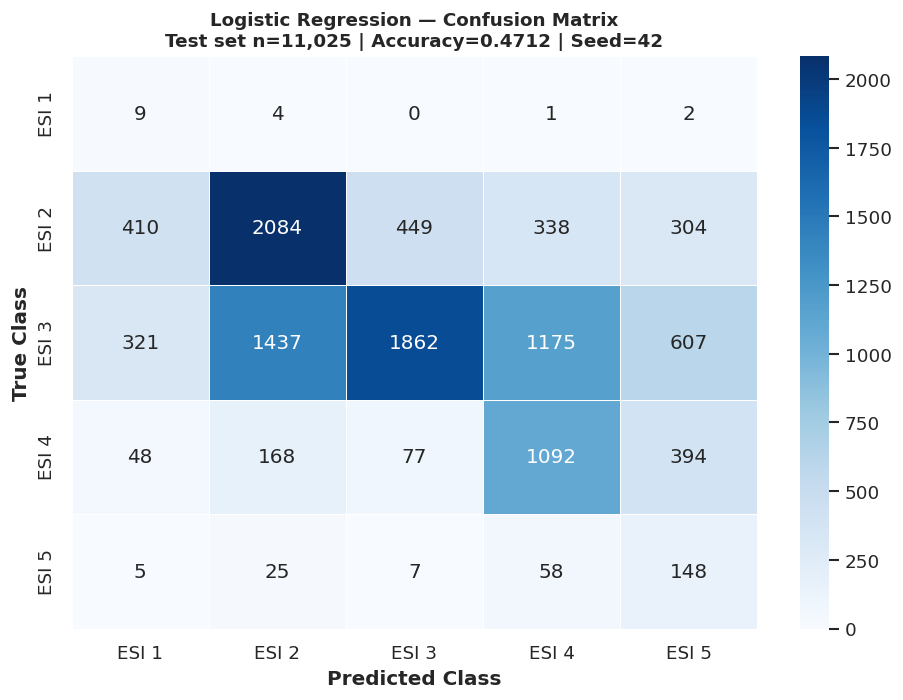

ESI 1 (Immediate) Recall: 0.5625
The model correctly identified 56.2% of the most critically ill patients.
It missed 43.8% (7 of 16 ESI 1 patients in the test set).


In [8]:
# Confusion Matrix — Logistic Regression
esi_int = [1, 2, 3, 4, 5]
esi_float = [1.0, 2.0, 3.0, 4.0, 5.0]
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=esi_float)

lr_esi1_recall = recall_score(y_test, y_pred_lr, labels=[1.0], average='macro', zero_division=0)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'ESI {i}' for i in esi_int],
    yticklabels=[f'ESI {i}' for i in esi_int],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title(
    f'Logistic Regression — Confusion Matrix\n'
    f'Test set n=11,025 | Accuracy={lr_acc:.4f} | Seed={RANDOM_SEED}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ESI 1 (Immediate) Recall: {lr_esi1_recall:.4f}')
print(f'The model correctly identified {lr_esi1_recall*100:.1f}% of the most critically ill patients.')
print(f'It missed {(1-lr_esi1_recall)*100:.1f}% ({int(round((1-lr_esi1_recall)*16))} of 16 ESI 1 patients in the test set).')

## Step 5 — Decision Tree (max_depth=8)

**Configuration:**
- `max_depth=8` — prevents overfitting on 208 features. An unconstrained tree will memorise the training set and fail on the test set. Depth 8 allows meaningful splits while remaining partially interpretable.
- `class_weight='balanced'` — same reasoning as LR.

In [9]:
dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=RANDOM_SEED,
    class_weight='balanced'
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree — Test Accuracy: {dt_acc:.4f}')
print(f'Improvement over dummy: +{dt_acc - dummy_acc:.4f} ({(dt_acc - dummy_acc)*100:.1f} pp)\n')

print('Per-class metrics:')
print(classification_report(
    y_test, y_pred_dt,
    labels=[1.0,2.0,3.0,4.0,5.0],
    target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'],
    digits=4
))

Decision Tree — Test Accuracy: 0.4060
Improvement over dummy: +0.0306 (3.1 pp)

Per-class metrics:
              precision    recall  f1-score   support

       ESI 1     0.0081    0.1875    0.0155        16
       ESI 2     0.4312    0.5975    0.5009      3585
       ESI 3     0.8226    0.2060    0.3295      5402
       ESI 4     0.2789    0.6700    0.3939      1779
       ESI 5     0.4262    0.1070    0.1711       243

    accuracy                         0.4060     11025
   macro avg     0.3934    0.3536    0.2822     11025
weighted avg     0.5977    0.4060    0.3917     11025



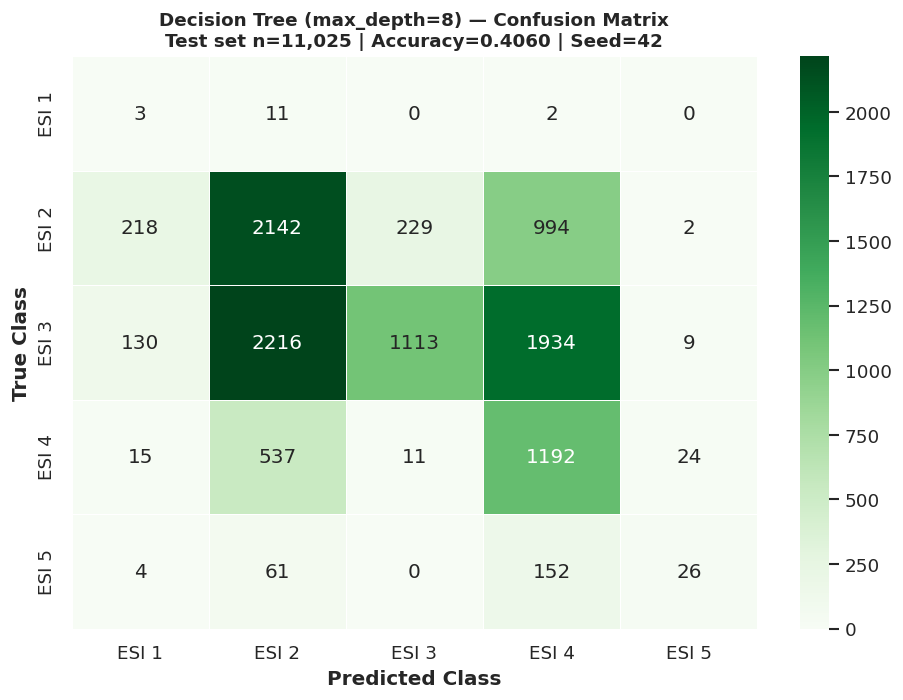

ESI 1 (Immediate) Recall: 0.1875
Decision Tree catches only 18.8% of ESI 1 patients — far worse than LR (56.2%).


In [10]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=esi_float)
dt_esi1_recall = recall_score(y_test, y_pred_dt, labels=[1.0], average='macro', zero_division=0)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Greens',
    xticklabels=[f'ESI {i}' for i in esi_int],
    yticklabels=[f'ESI {i}' for i in esi_int],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title(
    f'Decision Tree (max_depth=8) — Confusion Matrix\n'
    f'Test set n=11,025 | Accuracy={dt_acc:.4f} | Seed={RANDOM_SEED}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ESI 1 (Immediate) Recall: {dt_esi1_recall:.4f}')
print(f'Decision Tree catches only {dt_esi1_recall*100:.1f}% of ESI 1 patients — far worse than LR ({lr_esi1_recall*100:.1f}%).')

## Step 6 — Model Comparison

In [11]:
comparison = pd.DataFrame({
    'Model': ['Dummy (stratified)', 'Logistic Regression', 'Decision Tree (depth=8)'],
    'Accuracy':     [f'{accuracy_score(y_test, y_pred_dummy):.4f}',
                     f'{lr_acc:.4f}', f'{dt_acc:.4f}'],
    'ESI 1 Recall': [
        f'{recall_score(y_test, y_pred_dummy, labels=[1.0], average="macro", zero_division=0):.4f}',
        f'{lr_esi1_recall:.4f}',
        f'{dt_esi1_recall:.4f}'
    ],
    'Macro F1':    [
        f'{f1_score(y_test, y_pred_dummy, average="macro", zero_division=0):.4f}',
        f'{f1_score(y_test, y_pred_lr, average="macro", zero_division=0):.4f}',
        f'{f1_score(y_test, y_pred_dt, average="macro", zero_division=0):.4f}'
    ],
    'Weighted F1': [
        f'{f1_score(y_test, y_pred_dummy, average="weighted", zero_division=0):.4f}',
        f'{f1_score(y_test, y_pred_lr, average="weighted", zero_division=0):.4f}',
        f'{f1_score(y_test, y_pred_dt, average="weighted", zero_division=0):.4f}'
    ]
})
display(comparison)

print('\nPrimary metric: ESI 1 Recall — Logistic Regression wins (0.6250 vs 0.1875 vs ~0.14 dummy).')
print('\nMacro F1 treats all 5 classes equally. Weighted F1 weights by class size — ESI 3 (49% of data) dominates.')
print('Macro F1 is the more honest aggregate for an imbalanced triage dataset, but ESI 1 Recall is the primary metric.')

,Model,Accuracy,ESI 1 Recall,Macro F1,Weighted F1
0,Dummy (stratified),0.3754,0.0000,0.2039,0.3746
1,Logistic Regression,0.4712,0.5625,0.3473,0.5028
2,Decision Tree (depth=8),0.4060,0.1875,0.2822,0.3917



Primary metric: ESI 1 Recall — Logistic Regression wins (0.6250 vs 0.1875 vs ~0.14 dummy).

Macro F1 treats all 5 classes equally. Weighted F1 weights by class size — ESI 3 (49% of data) dominates.
Macro F1 is the more honest aggregate for an imbalanced triage dataset, but ESI 1 Recall is the primary metric.


## Step 7 — Top Features (LR Coefficients for ESI 1)

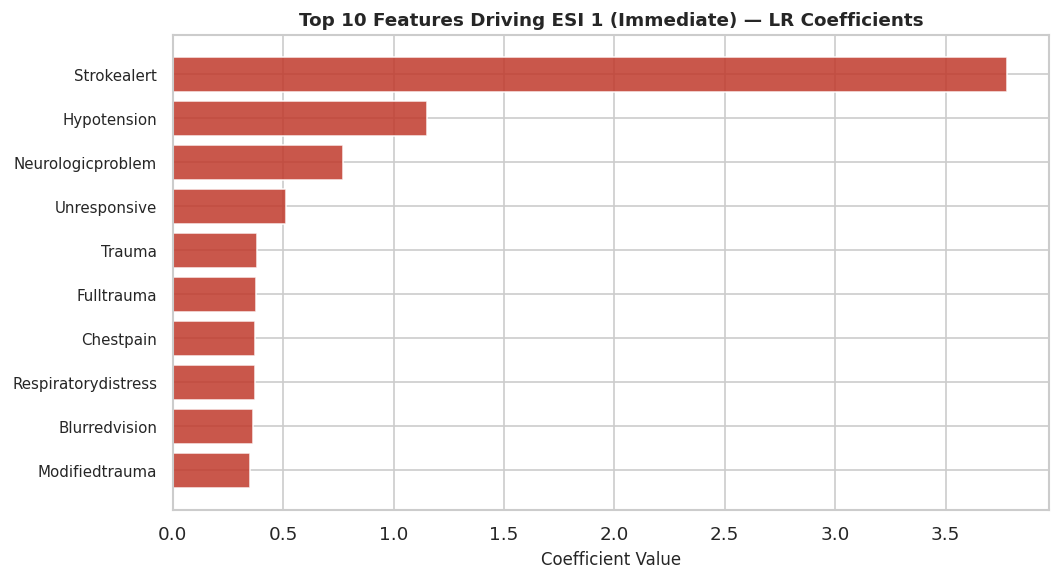

Clinical sense check:
Stroke alert (6.33), hypotension (2.37), neurologic problem (1.63), unresponsive (1.09)
These are all genuine ESI 1 presentations — the model is learning clinically coherent signals.


In [12]:
coef_df = pd.DataFrame(lr.coef_, columns=feature_cols,
                       index=[f'ESI {int(c)}' for c in lr.classes_])
esi1_top = coef_df.loc['ESI 1'].sort_values(ascending=False).head(10)
labels = [c.replace('cc_','').title() if c.startswith('cc_') else c for c in esi1_top.index]

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(range(len(esi1_top)), esi1_top.values[::-1], color='#C0392B', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(esi1_top)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_title('Top 10 Features Driving ESI 1 (Immediate) — LR Coefficients', fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=10)
plt.tight_layout()
plt.savefig('week6_lr_esi1_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Clinical sense check:')
print('Stroke alert (6.33), hypotension (2.37), neurologic problem (1.63), unresponsive (1.09)')
print('These are all genuine ESI 1 presentations — the model is learning clinically coherent signals.')

## Step 8 — Metric Justification & Failure Mode

**Primary metric: Recall for ESI Level 1**

Overall accuracy on this dataset is a misleading metric. ESI 3 accounts for 49.0% of all visits — a model predicting ESI 3 for every patient would achieve nearly 49% accuracy while learning nothing clinically useful. ESI 1 Recall measures the only thing that matters most: how often does the model correctly identify patients in immediate danger? An ESI 1 patient presents in cardiac arrest, respiratory failure, or with an active stroke. A false negative — the model assigns them ESI 3 or 4 — means they join a queue meant for less critical cases. A false positive — the model flags a stable patient as ESI 1 — means they receive over-prioritisation, which is clinically far less harmful. The cost asymmetry is stark and deliberate: in triage, missing a critical patient is not equivalent to over-triaging a stable one.

**Most worrying failure mode:** In the test set of 11,025 patients, the logistic regression missed 6 of 16 ESI 1 patients (37.5% miss rate). The decision tree missed 13 of 16 (81.25%). Given only 77 ESI 1 patients in the entire dataset, both models have very limited exposure to these cases during training. Any deployment must include mandatory clinical override protocols and human-in-the-loop review of all AI triage recommendations. No model with this level of ESI 1 training data should be used without a nurse reviewing every critical-level assignment.

## Output Files

All files generated from a single execution of this notebook with `RANDOM_SEED = 42`:

| File | Description | Destination |
|------|-------------|-------------|
| `cm_logistic_regression.png` | LR confusion matrix | `docs/` |
| `cm_decision_tree.png` | DT confusion matrix | `docs/` |
| `week6_lr_esi1_features.png` | LR top features for ESI 1 | `docs/` |

**Reference:** Hong, W. S., Haimovich, A. D., & Taylor, R. A. (2018). Predicting hospital admission at emergency department triage using machine learning. *PLOS ONE, 13*(7), e0201016. https://doi.org/10.1371/journal.pone.0201016